# Linear optical properties for each component


* Absorption coefficient
  * title: "Absorption coefficient"
  * label: "absorption"

* Refractive index
  * title: "Refractive index"
  * label: "refractive"

* Extinction coefficient
  * title: "Extinction coefficient"
  * label: "extinction"

* Reflectivity
  * title: "Reflectivity"
  * label: "reflectivity"

* Energy-loss spectrum
  * title: "Energy-loss spectrum"
  * label: "energy-loss"


In [8]:
from vmatplot.linear_optical_properties import *
from vmatplot.commons import process_boundaries_rescaling, process_boundary
import matplotlib.pyplot as plt

def plot_linear_optical_property(suptitle, systems=None, properties=None, components="xx", layout="horizontal", unit="eV", boundary=(None, None), figure_size=(None, None)):

    ## Support information
    if suptitle.lower() in ["help", "support"]:
        help_info = lop_plotting_help()
        print(help_info)
        return

    ## properties labels and determination
    multi_prop_flag = None
    if isinstance(properties, str):
        multi_prop_flag = False
        formula_flag = identify_linear_optical_functions(properties)["flag"]
        formula_title = identify_linear_optical_functions(properties)["title"]
    elif isinstance(properties, list):
        formula_flags, formula_titles =[],[]
        for formula_input in properties:
            formula_flags.append(identify_linear_optical_functions(formula_input)["flag"])
            formula_titles.append(identify_linear_optical_functions(formula_input)["title"])
        if len(properties) == 1:
            multi_prop_flag = False
            formula_flag = formula_flags[0]
            formula_title = formula_titles[0]
        elif len(properties) > 1:
            multi_prop_flag = True
    if multi_prop_flag == True:
        print("We currently do not support multiple linear optical properties in one figure")
        return None

    ## multi component determination
    multi_comp_flag = None
    comp_labels, comp_aliases = [], []
    if isinstance(components, str):
        multi_comp_flag = False
        comp_labels.append(components)
        comp_aliases.append(f"{components}-component")
    elif isinstance(components, dict):
        if len(components) == 1:
            multi_comp_flag = False
            comp_labels.append(list(components.keys())[0])
            comp_aliases.append(list(components.values())[0])
        elif len(components) > 1:
            multi_comp_flag = True
            comp_labels.append(list(components.keys()))
            comp_aliases.append(list(components.values()))
    elif isinstance(components, list):
        if len(components) == 1:
            multi_comp_flag = False
        elif len(components) > 1:
            multi_comp_flag = True
        for comp_unit in components:
            if isinstance(comp_unit, dict):
                comp_labels.append(list(comp_unit.keys())[0])
                comp_aliases.append(list(comp_unit.values())[0])
            elif isinstance(comp_unit, str):
                comp_labels.append(comp_unit)
                comp_aliases.append(f"{comp_unit}-component")
    if multi_comp_flag == False:
            comp_label = comp_labels[0]
            comp_aliase = comp_aliases[0]

    ## figure settings
    layout_flag = "horizontal" if layout.lower() not in ["vertical", "ver","v"] else "vertical"
    if multi_comp_flag == False:
        ## figure settings
        fig_setting = canvas_setting() if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
        plt.figure(figsize=fig_setting[0], dpi=fig_setting[1])
        params = fig_setting[2]
        plt.rcParams.update(params)

    elif multi_comp_flag == True:
        ## figure settings
        if len(components) == 2:
            if layout_flag == "horizontal":
                fig_setting = canvas_setting(16, 6) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
                params = fig_setting[2]
                plt.rcParams.update(params)
                fig, axs = plt.subplots(1, 2, figsize=fig_setting[0], dpi=fig_setting[1])
                axs = axs.reshape(1, 2)
                axes_element = [axs[0, i] for i in range(2)]
            else:
                fig_setting = canvas_setting(8, 12) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
                params = fig_setting[2]
                plt.rcParams.update(params)
                fig, axs = plt.subplots(2, 1, figsize=fig_setting[0], dpi=fig_setting[1])
                axs = axs.reshape(2, 1)
                axes_element = [axs[i, 0] for i in range(2)]
        elif len(components) in [3, 5, 7]:
            if layout_flag == "horizontal":
                fig_setting = canvas_setting(8*len(components), 6) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
                params = fig_setting[2]
                plt.rcParams.update(params)
                fig, axs = plt.subplots(1, len(components), figsize=fig_setting[0], dpi=fig_setting[1])
                axes_element = [axs[i] for i in range(len(components))]
            else:
                fig_setting = canvas_setting(10, 6*len(components)) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
                params = fig_setting[2]
                plt.rcParams.update(params)
                fig, axs = plt.subplots(len(components), 1, figsize=fig_setting[0], dpi=fig_setting[1])
                axes_element = [axs[i] for i in range(len(components))]
        elif len(components) in [4, 6, 8]:
            if layout_flag == "horizontal":
                fig_setting = canvas_setting(8*len(components)/2, 12) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
                params = fig_setting[2]
                plt.rcParams.update(params)
                fig, axs = plt.subplots(2, int(len(components)/2), figsize=fig_setting[0], dpi=fig_setting[1])
                # axes_element = [axs[i, j] for j in range(int(len(components)/2)) for i in range(2)]
                axes_element = [axs[i, j] for i in range(2) for j in range(int(len(components)/2))]
            else:
                fig_setting = canvas_setting(16, 6*len(components)/2+1) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
                params = fig_setting[2]
                plt.rcParams.update(params)
                fig, axs = plt.subplots(int(len(components)/2), 2, figsize=fig_setting[0], dpi=fig_setting[1])
        elif len(components) == 9:
            if layout_flag == "horizontal":
                fig_setting = canvas_setting(24, 18) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
                params = fig_setting[2]
                plt.rcParams.update(params)
                fig, axs = plt.subplots(3, 3, figsize=fig_setting[0], dpi=fig_setting[1])
                axes_element = [axs[i, j] for i in range(3) for j in range(3)]
            else:
                fig_setting = canvas_setting(24, 18) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
                params = fig_setting[2]
                plt.rcParams.update(params)
                fig, axs = plt.subplots(3, 3, figsize=fig_setting[0], dpi=fig_setting[1])
                axes_element = [axs[i, j] for j in range(3) for i in range(3)]

    ## boundaries processing
    photon_start, photon_end = process_boundary(boundary)

    ## identify x-axis unit
    var_label = "wavelength" if unit and unit.lower() == "nm" else "energy"
    xaxis_str = "Photon wavelength (nm)" if var_label == "wavelength" else "Photon energy (eV)"

    ## systems information
    dataset = dielectric_systems_list(systems)

    ## suptitle
    if multi_comp_flag == False:
        plt.title(f"{formula_title} for {comp_aliase} {suptitle}", fontsize=fig_setting[3][0])
    elif multi_comp_flag == True:
        fig.suptitle(f"{formula_title} {suptitle}", fontsize=fig_setting[3][0])

    ## data plotting
    if multi_comp_flag == False:
        plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

        # component key
        current_component = comp_label.lower()
        data_key_real = f"density_{current_component}_real"
        data_key_imag = f"density_{current_component}_imag"

        # curve plotting
        for _, data in enumerate(dataset):
            energy_real, density_energy_real = extract_part(data[1]["density_energy_real"], data[1][data_key_real], photon_start, photon_end)
            energy_imag, density_energy_imag = extract_part(data[1]["density_energy_imag"], data[1][data_key_imag], photon_start, photon_end)
            frequency_real = energy_to_frequency(energy_real)
            wavelength_real = energy_to_wavelength(energy_real)
            if formula_flag == "absorption":
                variables = current_lop(formula_flag,frequency_real,density_energy_real,density_energy_imag)
            else:
                variables = current_lop(formula_flag,density_energy_real,density_energy_imag)
            if var_label == "energy":
                plt.plot(energy_real, variables, color=color_sampling(data[2])[1], ls=data[3], alpha=data[4], lw=data[5], label=f"{data[0]}")
            elif var_label == "wavelength":
                plt.plot(wavelength_real, variables, color=color_sampling(data[2])[1], ls=data[3], alpha=data[4], lw=data[5], label=f"{data[0]}")
        
        # axis labels
        plt.ylabel(f"{formula_title}")
        plt.xlabel(xaxis_str)

        # legends and scientific notation
        plt.legend(loc="best")
        plt.ticklabel_format(style="sci", axis="y", scilimits=(-3,3), useOffset=False, useMathText=True)

        plt.tight_layout()

    elif multi_comp_flag == True:
        for subplot_index in range(len(components)):
            ax = axes_element[subplot_index]
            ax.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

            # components index and subtitles
            component_index = subplot_index
            ax.set_title(comp_aliases[component_index])

            # current component key and label
            current_component = comp_labels[component_index].lower()
            data_key_real = f"density_{current_component}_real"
            data_key_imag = f"density_{current_component}_imag"

            # curve plotting
            for _, data in enumerate(dataset):
                energy_real, density_energy_real = extract_part(data[1]["density_energy_real"], data[1][data_key_real], photon_start, photon_end)
                energy_imag, density_energy_imag = extract_part(data[1]["density_energy_imag"], data[1][data_key_imag], photon_start, photon_end)
                frequency_real = energy_to_frequency(energy_real)
                wavelength_real = energy_to_wavelength(energy_real)
                if formula_flag == "absorption":
                    variables = current_lop(formula_flag,frequency_real,density_energy_real,density_energy_imag)
                else:
                    variables = current_lop(formula_flag,density_energy_real,density_energy_imag)
                if var_label == "energy":
                    ax.plot(energy_real, variables, color=color_sampling(data[2])[1], ls=data[3], alpha=data[4], lw=data[5], label=f"{data[0]}")
                elif var_label == "wavelength":
                    ax.plot(wavelength_real, variables, color=color_sampling(data[2])[1], ls=data[3], alpha=data[4], lw=data[5], label=f"{data[0]}")
            
            # axis labels
            if layout_flag == "horizontal":
                if len(components) == 2:
                    ax.set_xlabel(xaxis_str)
                    if subfig


            # legends and scientific notation
            ax.legend(loc="best")
            ax.ticklabel_format(style="sci", axis="y", scilimits=(-3,3), useOffset=False, useMathText=True)

            plt.tight_layout()


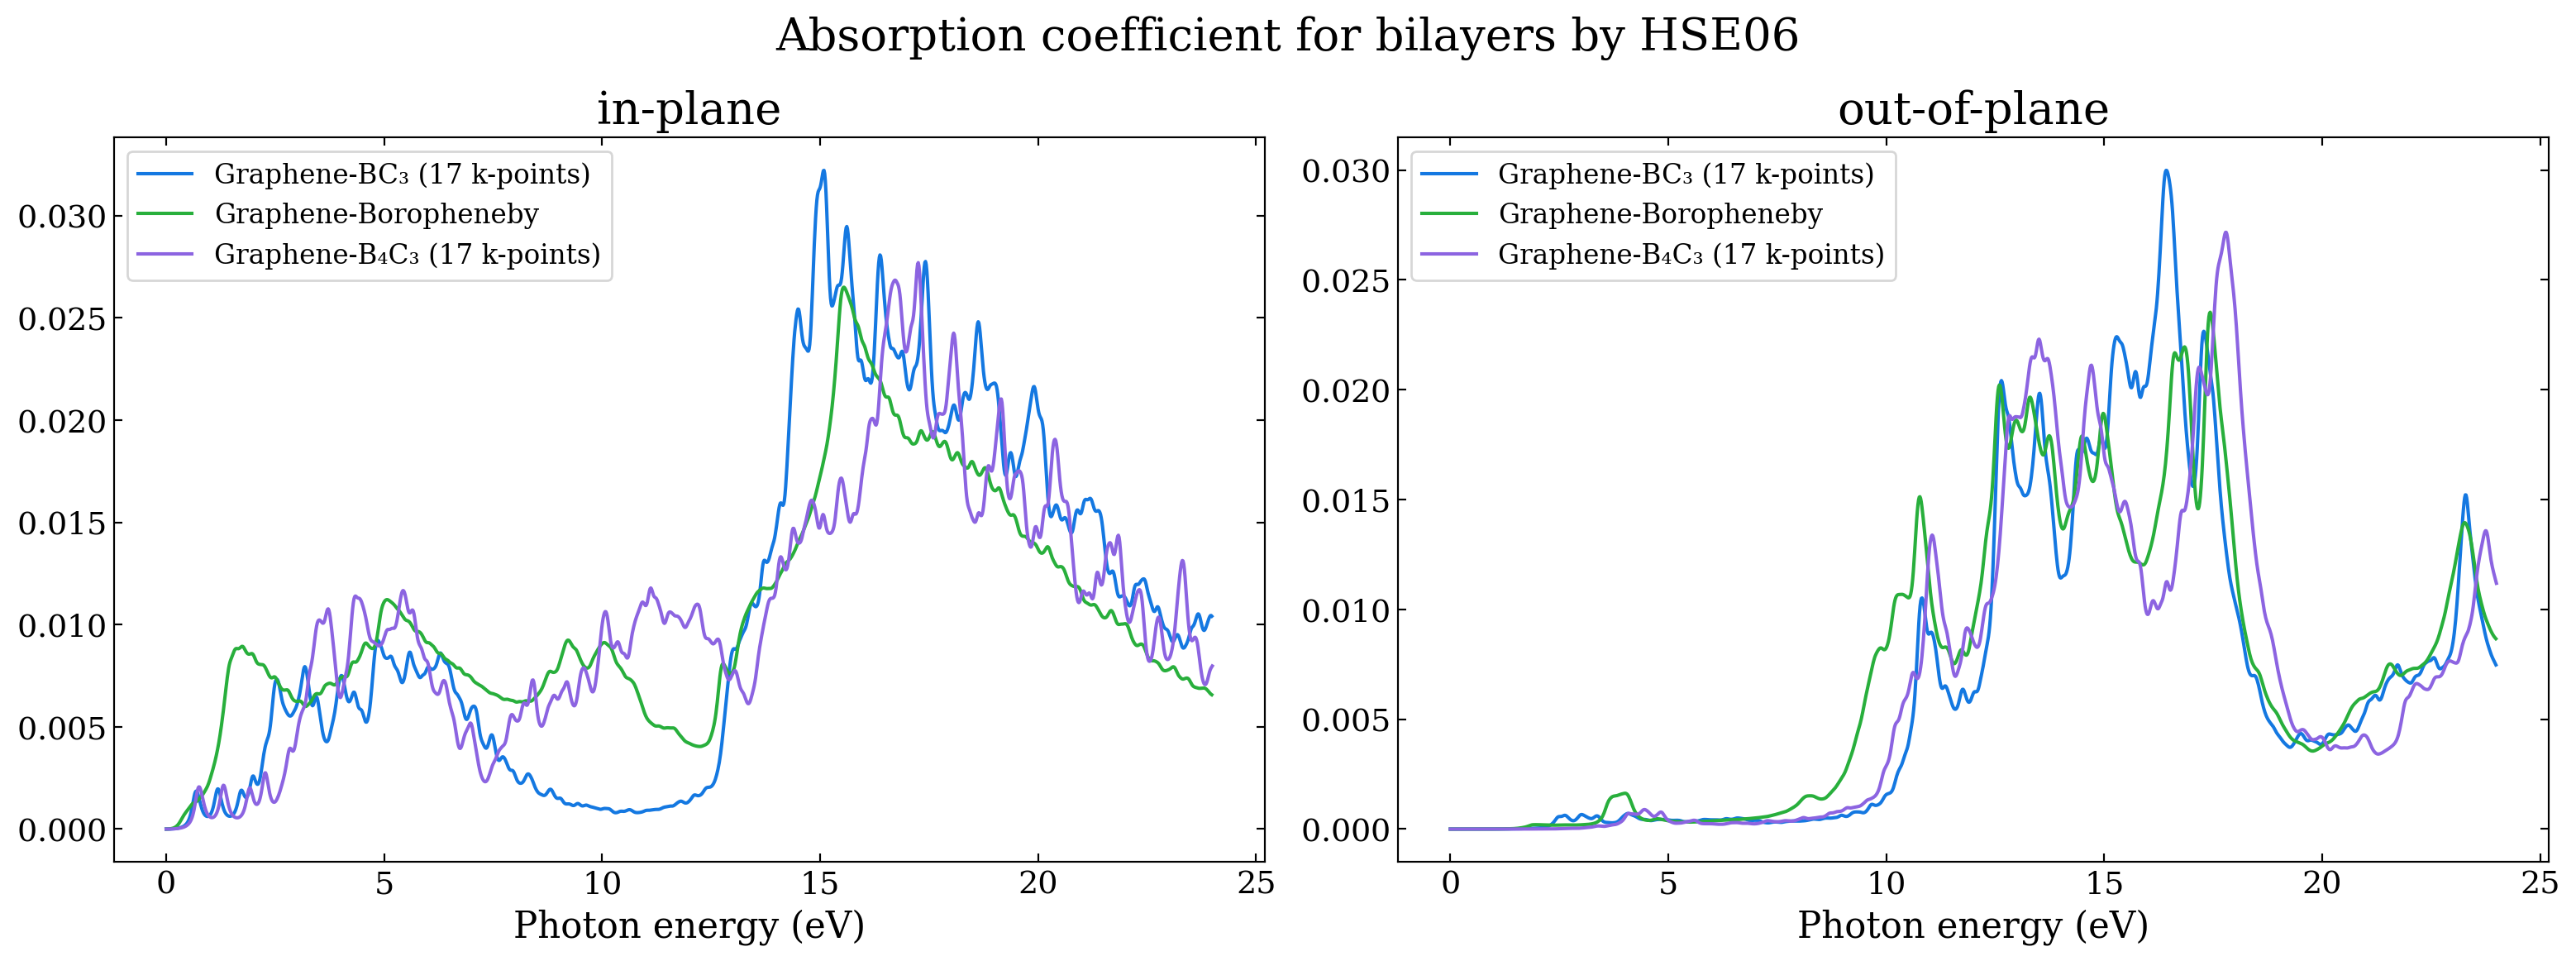

In [9]:
systems = [["Graphene-BC₃ (17 k-points)", "5_Dielectric_function/E_Graphene-BC3_HSE_K17", "blue"],
           ["Graphene-Boropheneby", "5_Dielectric_function/F_Graphene-Borophene_HSE_K65_Accurate", "green"],
           ["Graphene-B₄C₃ (17 k-points)", "5_Dielectric_function/G_Graphene-B4C3_HSE_K17", "violet"]]

components = [{"xx":"in-plane"}, {"zz":"out-of-plane"}]
# components = [{"xx":"in-plane"}, "yy", {"zz":"out-of-plane"}]
# components = [{"xx":"in-plane"}, "yy", {"zz":"out-of-plane"}, "xy"]
# components = [{"xx":"in-plane"}, "yy", {"zz":"out-of-plane"}, "xy", "yz"]
# components = [{"xx":"in-plane"}, "yy", {"zz":"out-of-plane"}, "xy", "yz", "zx"]
# components = [{"xx":"in-plane"}, "yy", {"zz":"out-of-plane"}, "xy", "yz", "zx", "yx"]
# components = [{"xx":"in-plane"}, "yy", {"zz":"out-of-plane"}, "xy", "yz", "zx", "yx", "zy"]
# components = [{"xx":"in-plane"}, "yy", {"zz":"out-of-plane"}, "xy", "yz", "zx", "yx", "zy", "xz"]

boundary = 24
layout = "hor"

plot_linear_optical_property("for bilayers by HSE06", systems, "absorption", components, layout, "eV", boundary)

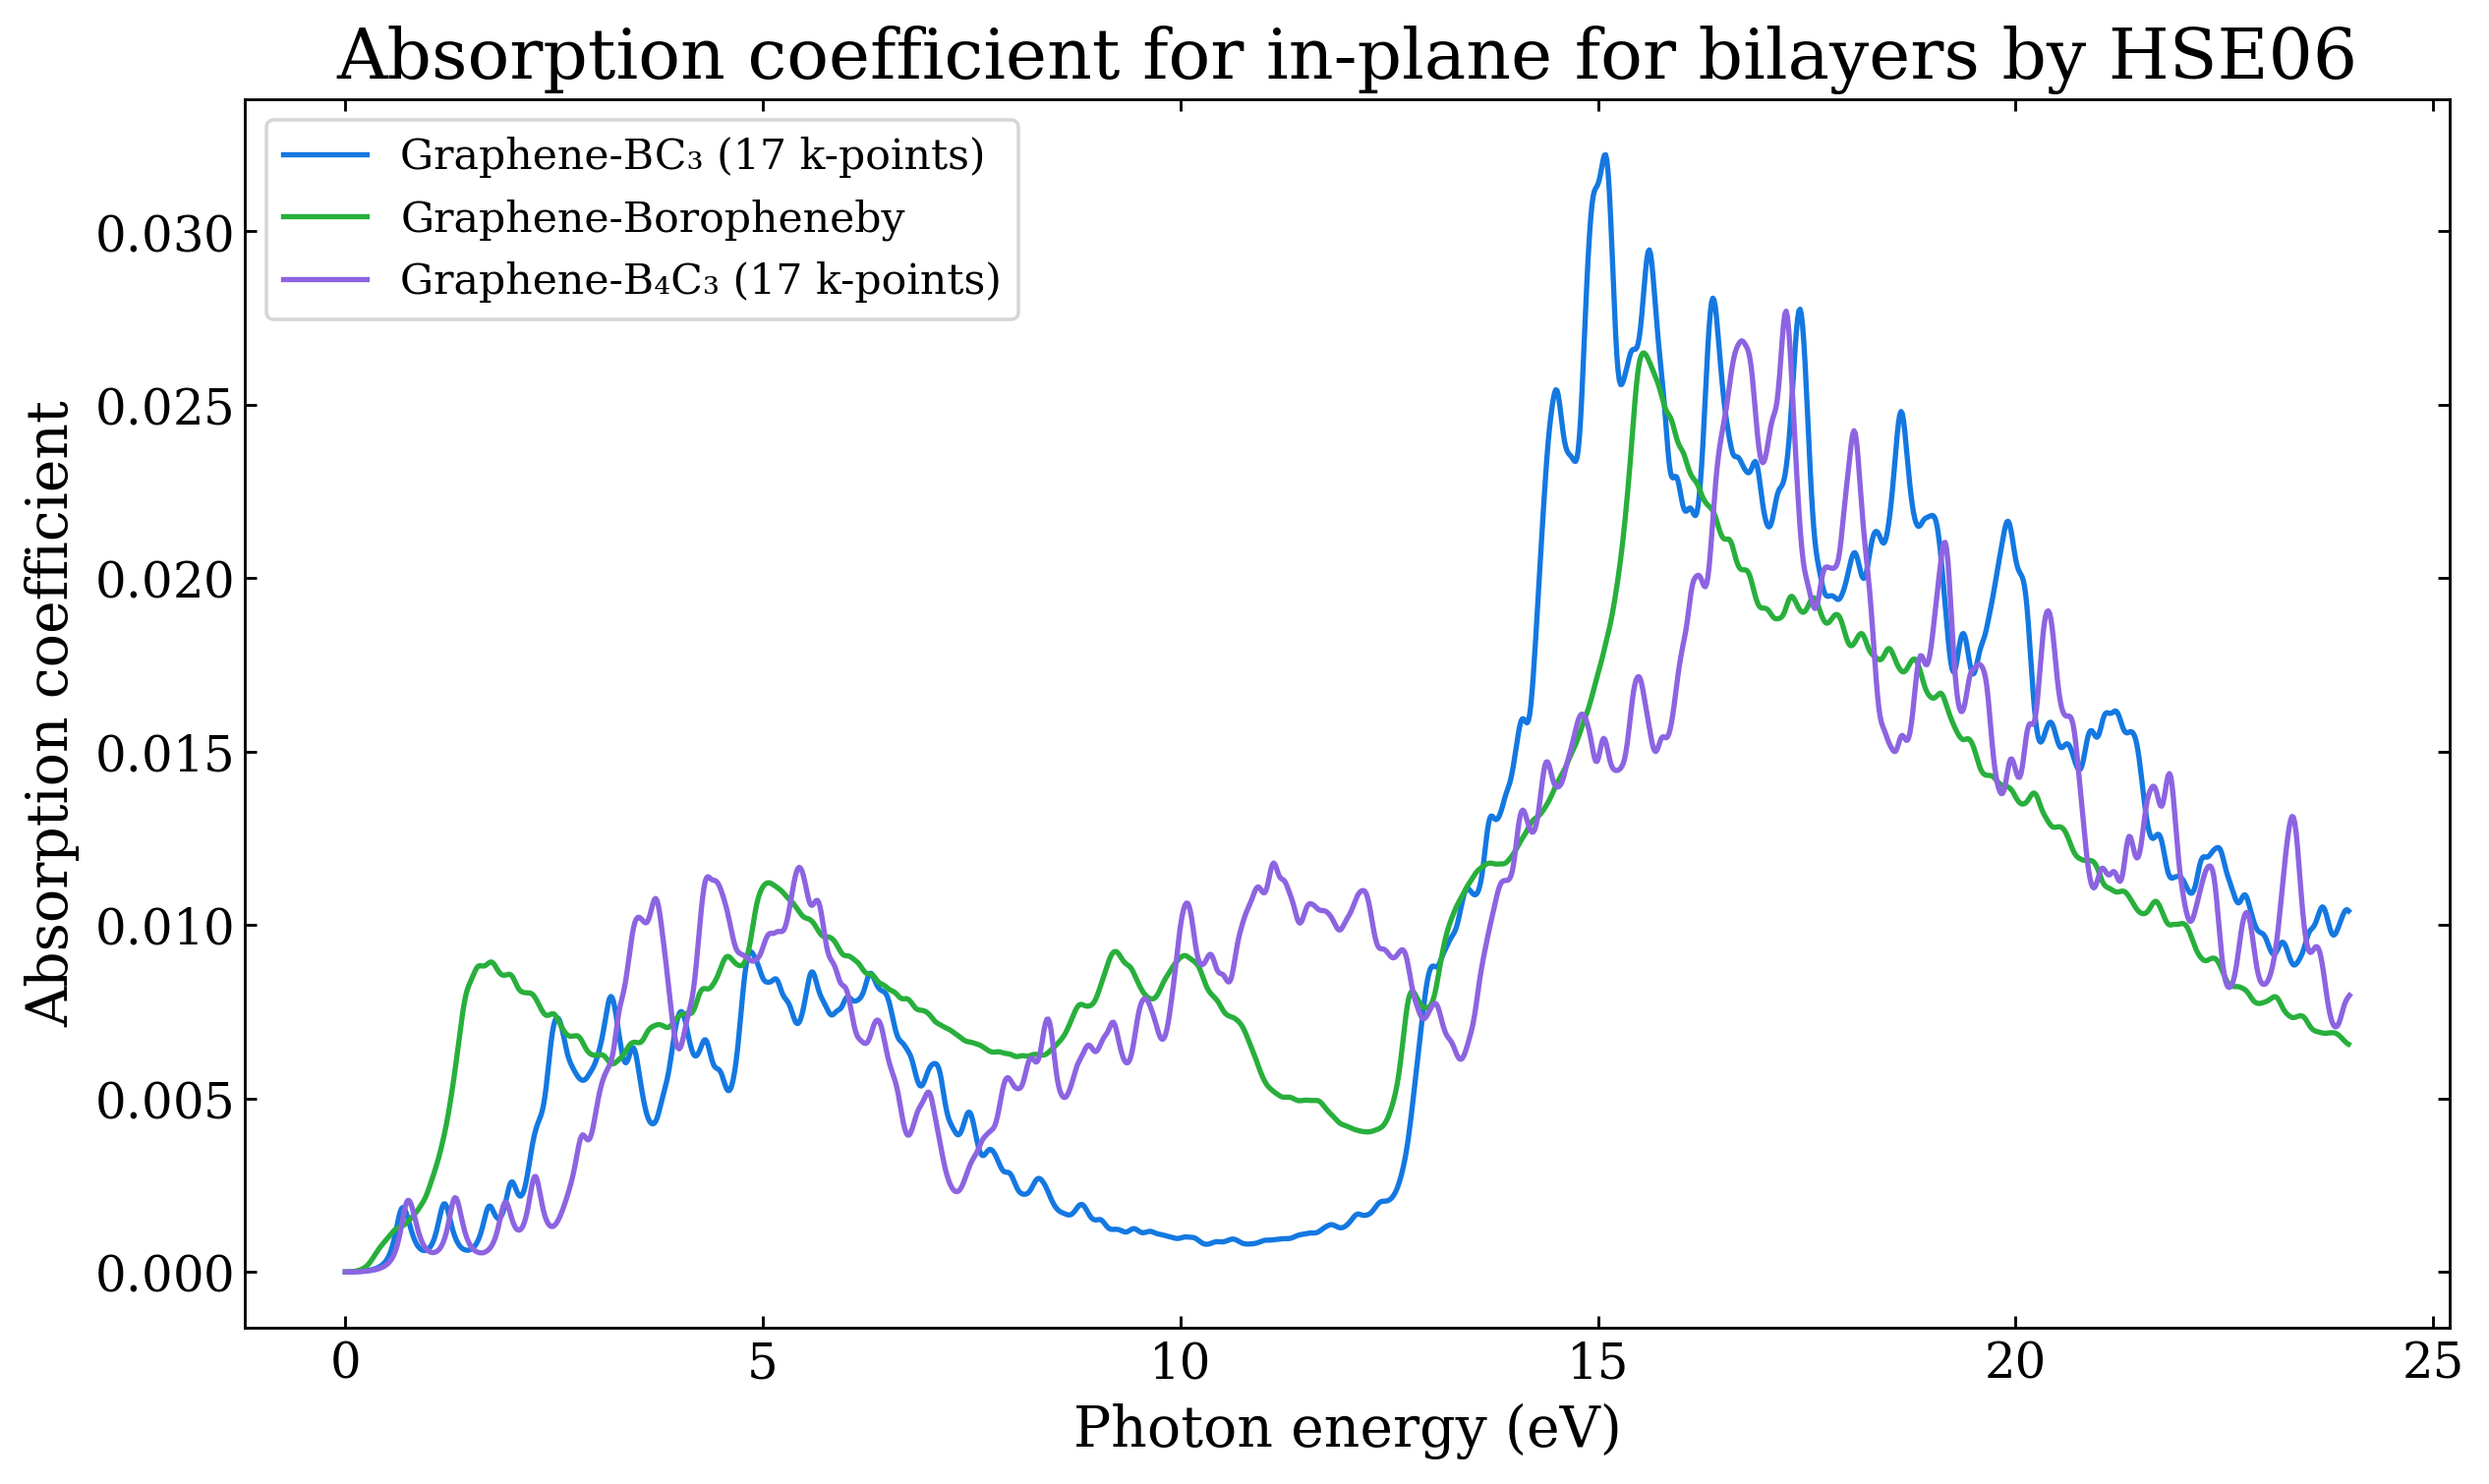

In [3]:
systems = [["Graphene-BC₃ (17 k-points)", "5_Dielectric_function/E_Graphene-BC3_HSE_K17", "blue"],
           ["Graphene-Boropheneby", "5_Dielectric_function/F_Graphene-Borophene_HSE_K65_Accurate", "green"],
           ["Graphene-B₄C₃ (17 k-points)", "5_Dielectric_function/G_Graphene-B4C3_HSE_K17", "violet"]]


component = {"xx":"in-plane"}

boundary = 24
layout = "hor"

plot_linear_optical_property("for bilayers by HSE06", systems, "absorption", component, layout, "eV", boundary)
